# Starter Notebook: Phishing Websites

This dataset contains handcrafted URL/domain/page features for detecting phishing websites. The task is binary classification: distinguish phishing websites from legitimate websites.


## General Workflow

Use this notebook as a starting point. Your goal is to reason about the dataset, build multiple supervised learning models, and justify your final choice.

Recommended workflow:

1. Load and inspect the dataset.
2. Identify the target variable and the feature matrix.
3. Explore the data with summary statistics and visualizations.
4. Prepare the data for modeling.
5. Try feature selection.
6. Optionally try feature extraction or basis function expansion.
7. Train several appropriate supervised learning models.
8. Evaluate and compare the models using suitable metrics.
9. Summarize which model worked best and why.


## Dataset-Specific Notes

Target column: `Result`

Original labels:

- `-1`: phishing
- `1`: legitimate

For evaluation, encode phishing as the positive class (`1`) and legitimate as the negative class (`0`). In cybersecurity, false negatives are important because they are phishing websites predicted as legitimate.


***
# Laboratory exercise no.5
***

## 1. Imports

Import the libraries you need for data analysis, visualization, preprocessing, modeling, and evaluation.


In [65]:
# TODO: import libraries

RANDOM_STATE = 42

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve)
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier



## 2. Loading the Data

Load the prepared single-file CSV version of the Phishing Websites dataset. The original ARFF file has already been converted to a normal CSV with feature names in the first row.


In [66]:
DATA_PATH = "path/to/phishing_websites_dataset.csv"

# TODO: set DATA_PATH to the location of your downloaded dataset.csv file
# TODO: load the CSV file into a DataFrame
# Example: df = pd.read_csv(DATA_PATH)

df=pd.read_csv("/content/dataset_2_phishing_websites.csv")

df.head()


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


## 3. Initial Inspection

Inspect the dataset shape, feature types, missing values, target distribution, and any dataset-specific issues.


In [67]:
# TODO: inspect the dataset
print("Dataset shape: ",df.shape[0], "rows and ", df.shape[1], "columns")
print("================================")
print()
print("Some information for the dataset: ")
df.info()
print("================================")
print()
print("Some description for the dataset: ")
df.describe()

Dataset shape:  11055 rows and  31 columns

Some information for the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL            

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [68]:
df.isnull().sum()

,0
having_IP_Address,0
URL_Length,0
Shortining_Service,0
having_At_Symbol,0
double_slash_redirecting,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
Domain_registeration_length,0
Favicon,0


In [69]:
print("The dataset does not have any missing values.")

The dataset does not have any missing values.


In [70]:
print("Target distribution: ")
print(df['Result'].value_counts())

Target distribution: 
Result
 1    6157
-1    4898
Name: count, dtype: int64


In [71]:
print("We can say that the dataset is fairly balanced.")

We can say that the dataset is fairly balanced.


In [72]:
print("Unique values: ")
for col in df.columns:
  print(f"{col}: {df[col].unique()}")

Unique values: 
having_IP_Address: [-1  1]
URL_Length: [ 1  0 -1]
Shortining_Service: [ 1 -1]
having_At_Symbol: [ 1 -1]
double_slash_redirecting: [-1  1]
Prefix_Suffix: [-1  1]
having_Sub_Domain: [-1  0  1]
SSLfinal_State: [-1  1  0]
Domain_registeration_length: [-1  1]
Favicon: [ 1 -1]
port: [ 1 -1]
HTTPS_token: [-1  1]
Request_URL: [ 1 -1]
URL_of_Anchor: [-1  0  1]
Links_in_tags: [ 1 -1  0]
SFH: [-1  1  0]
Submitting_to_email: [-1  1]
Abnormal_URL: [-1  1]
Redirect: [0 1]
on_mouseover: [ 1 -1]
RightClick: [ 1 -1]
popUpWidnow: [ 1 -1]
Iframe: [ 1 -1]
age_of_domain: [-1  1]
DNSRecord: [-1  1]
web_traffic: [-1  0  1]
Page_Rank: [-1  1]
Google_Index: [ 1 -1]
Links_pointing_to_page: [ 1  0 -1]
Statistical_report: [-1  1]
Result: [-1  1]


In [73]:
print("From the dataset we can see that there are 3 values where -1 indicates phishing, 1 indicates legitimate and 0 indicates uncertainty.")

From the dataset we can see that there are 3 values where -1 indicates phishing, 1 indicates legitimate and 0 indicates uncertainty.


## 4. Visualization

Create visualizations that explain the dataset and the modeling challenge. Choose plots that are relevant for this specific problem.


In [74]:
df['Result'] = (df['Result'] == -1).astype(int)
X=df.drop(columns=['Result'])
y=df['Result']
feature_names=X.columns.tolist()

([<matplotlib.axis.XTick at 0x780af8502210>,
 [Text(0, 0, 'Legitimate'), Text(1, 0, 'Phishing')])

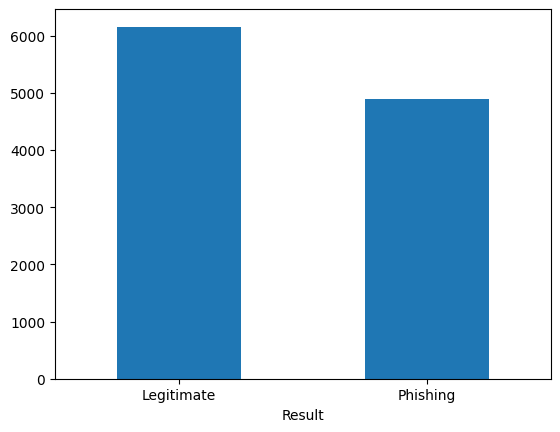

In [120]:
df['Result'].value_counts().plot.bar()
plt.xticks([0, 1], ['Legitimate', 'Phishing'], rotation=0)

<Axes: >

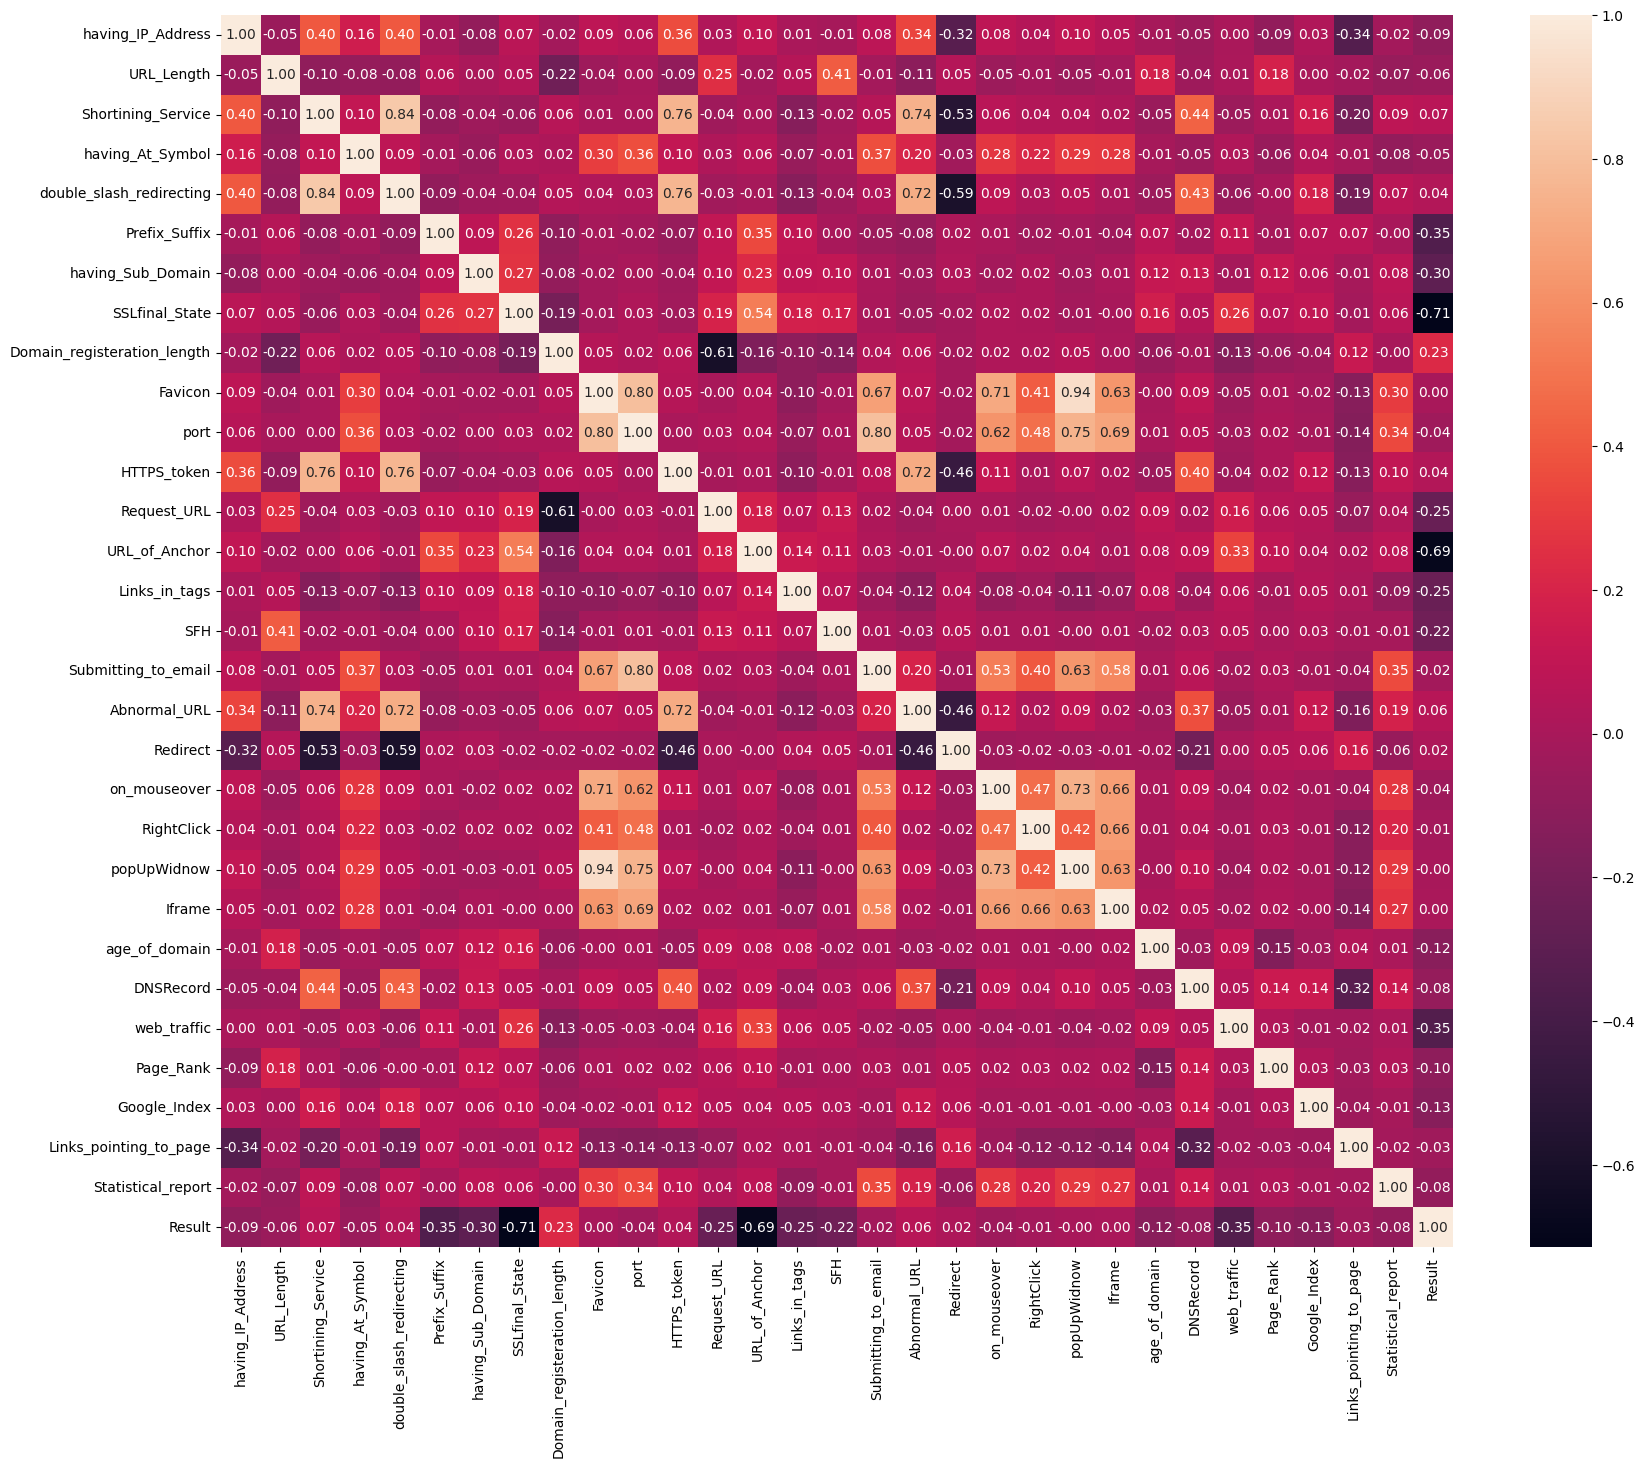

In [76]:
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", square=True)

The heatmap reveals high correlation between some features (for example Shortening_service and double_slash_redirecting ) which may affect linear models like LDA and Logistic Regression, but has little impact on tree-based models like Random Forest.

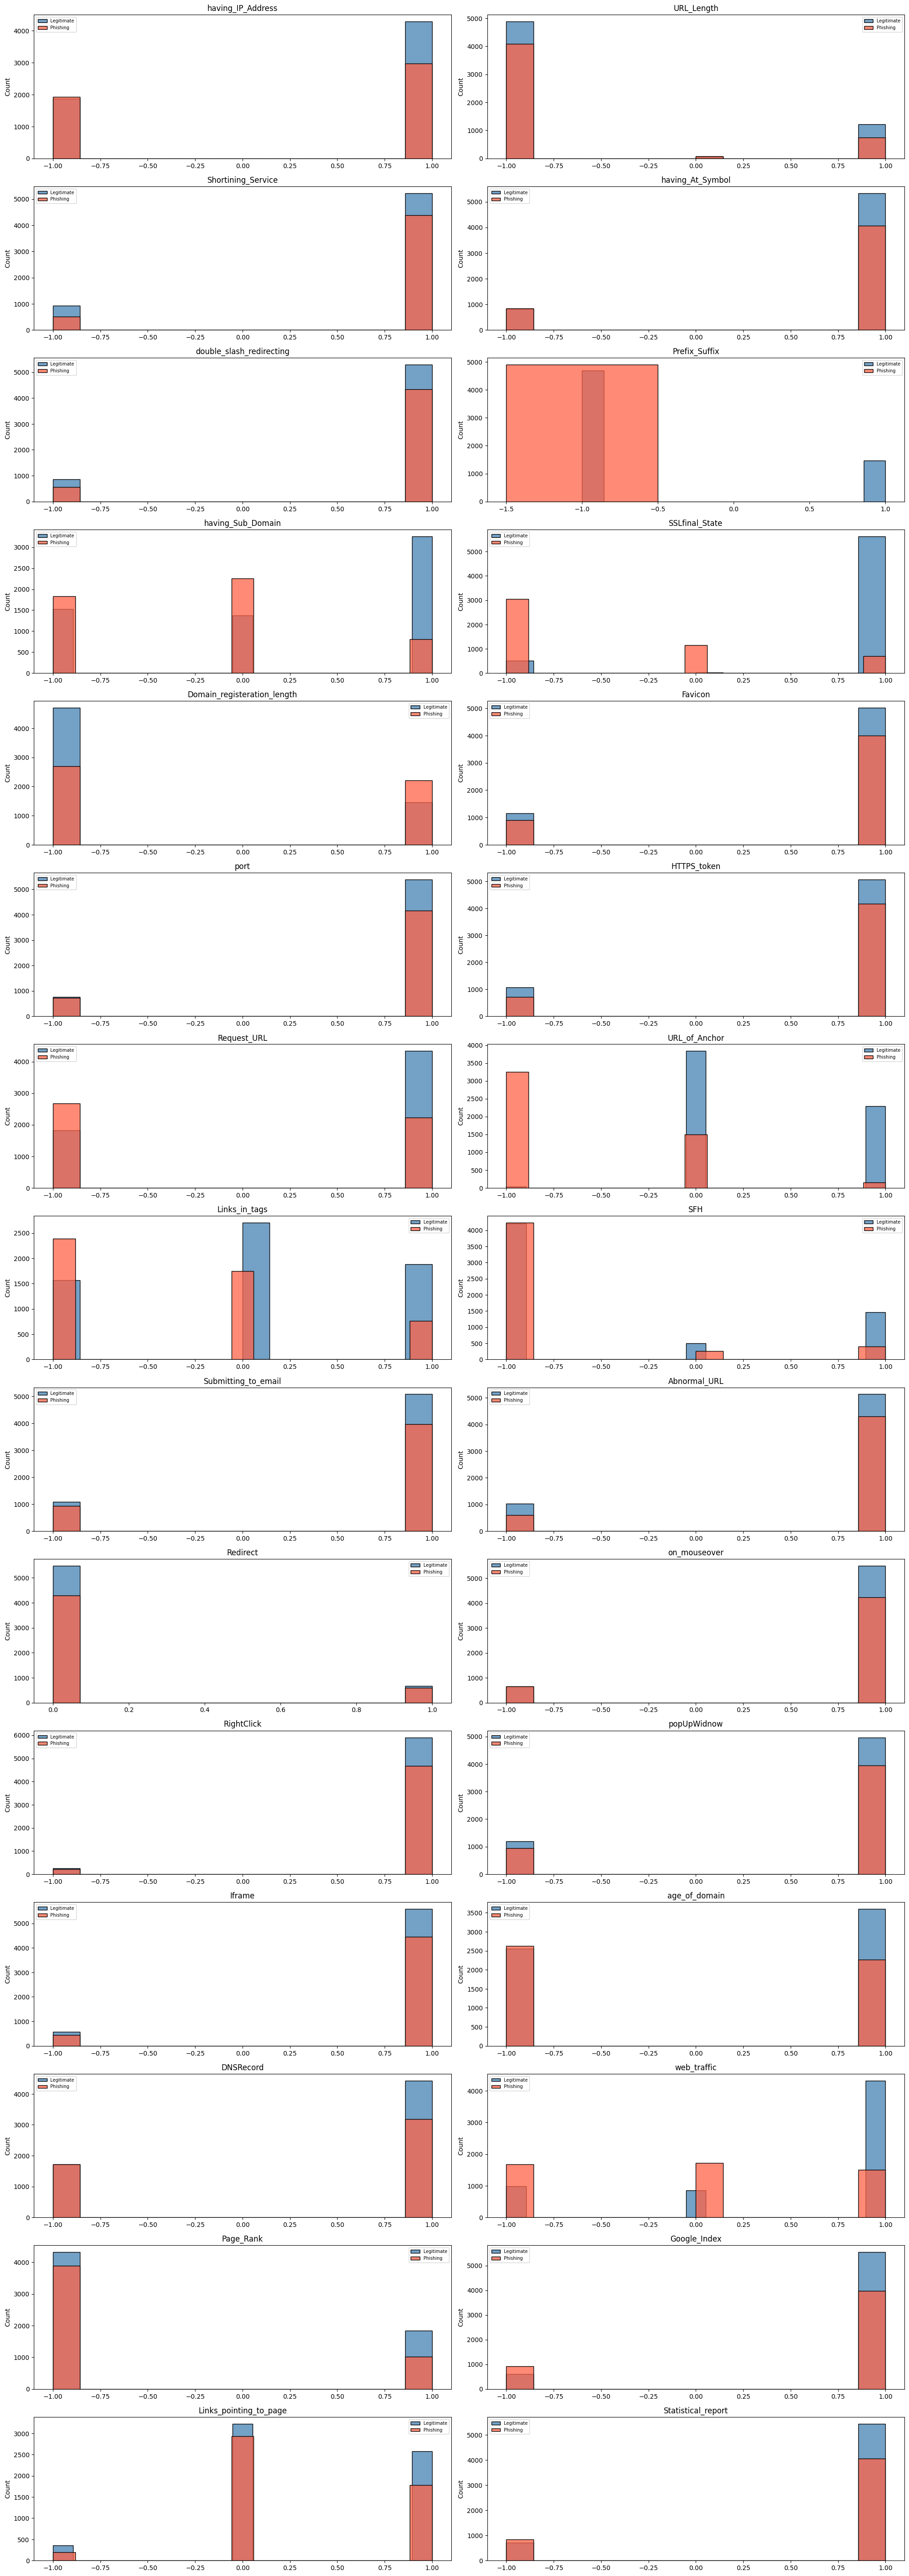

In [77]:
X_arr = X.values
y_arr = y.values
feature_names_list = X.columns.tolist()
number_of_features = len(feature_names_list)

fig = plt.figure(figsize=(20, 60))
for feat_i in range(number_of_features):
    ax = plt.subplot(16, 2, feat_i + 1)
    plt.title(feature_names_list[feat_i])
    sns.histplot(X_arr[y_arr == 0, feat_i], color='steelblue', label='Legitimate')
    sns.histplot(X_arr[y_arr == 1, feat_i], color='tomato', label='Phishing')
    plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

Each historgram shows us 3 bars and for each bar we can see how much of it is phishing (red) or legitimate (blue). For example for "Prefix_Suffix" we can see that at -1 it is mostly red which means it is phishing and at 1 is it mostly blue which means it is legitimate, so this feature is a good separator.

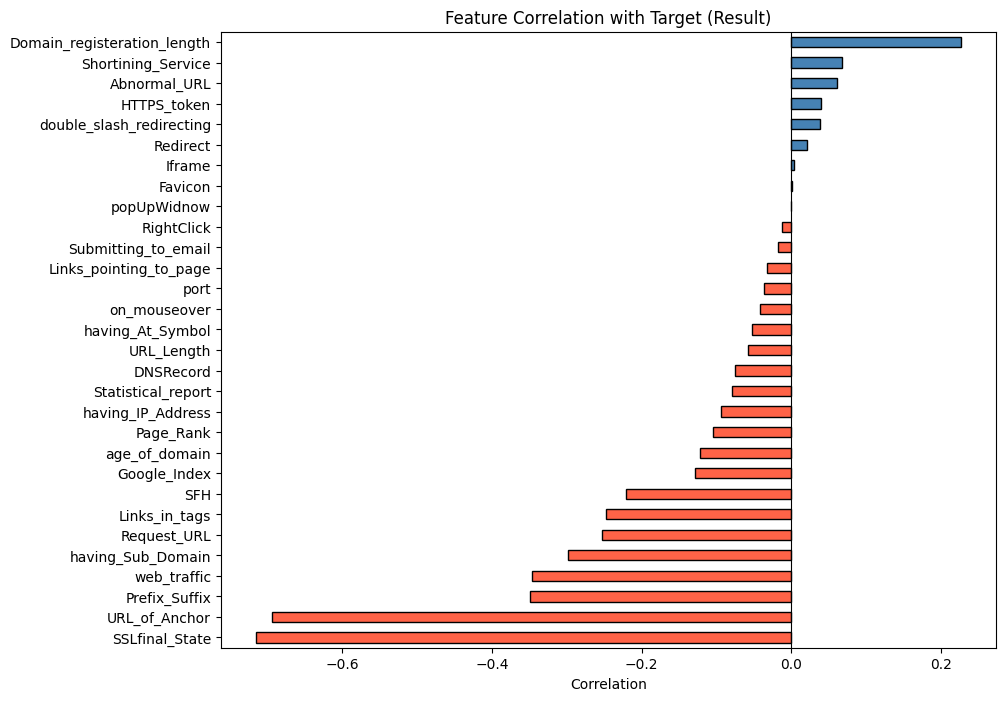

In [78]:
target_corr = df.corr(numeric_only=True)['Result'].drop('Result').sort_values()

plt.figure(figsize=(10, 8))
colors = ['tomato' if c < 0 else 'steelblue' for c in target_corr]
target_corr.plot.barh(color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Target (Result)')
plt.xlabel('Correlation')
plt.show()

* The red bars are negative correlation and tell us that the feature is associated with phishing.
* The blue bars are positive correlations and tell us that the feature is associated with legitimate sites.
* The longer bar, the stronger predictor
* The shorter bar, the weaker predictor

Conclusion:
-
* SSLFinal_State and URL_of_Anchor are good class separators
* The heatmap revealed high correlation between Shortining_Service and double_slash_redirecting (0.84), meaning they carry similar information.
* The dataset is slightly imbalanced (55.7% legitimate, 44.3% phishing)


***

## 5. Preprocessing

Prepare `X` and `y`, encode labels if needed, split the data, and decide what preprocessing each model requires.


In [79]:
# TODO: create X/y, split data, and define preprocessing pipelines
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print(f"Train set: {X_train.shape}")
print(f"Test set:    {X_test.shape}")


Train set: (8291, 30)
Test set:    (2764, 30)


In [80]:
# Scaling
scaler=StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [81]:
print(X.shape, y.shape)
print(y.value_counts())

(11055, 30) (11055,)
Result
0    6157
1    4898
Name: count, dtype: int64


## 6. Feature Selection

Try at least one feature selection method. Inspect or discuss the selected features.


***
# Mutual information

In [82]:
# TODO: apply feature selection
mi = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi, index=feature_names).sort_values(ascending=False)
print(mi_series)

SSLfinal_State                 0.349623
URL_of_Anchor                  0.334726
Prefix_Suffix                  0.079941
having_Sub_Domain              0.074753
web_traffic                    0.068246
Request_URL                    0.039611
Links_in_tags                  0.031297
SFH                            0.027145
Domain_registeration_length    0.021494
Google_Index                   0.012885
Links_pointing_to_page         0.010922
age_of_domain                  0.009984
HTTPS_token                    0.009684
Page_Rank                      0.009086
having_At_Symbol               0.008707
port                           0.007337
Statistical_report             0.007038
URL_Length                     0.006255
DNSRecord                      0.004736
Favicon                        0.004235
having_IP_Address              0.003955
Shortining_Service             0.002080
on_mouseover                   0.001010
RightClick                     0.000644
popUpWidnow                    0.000240


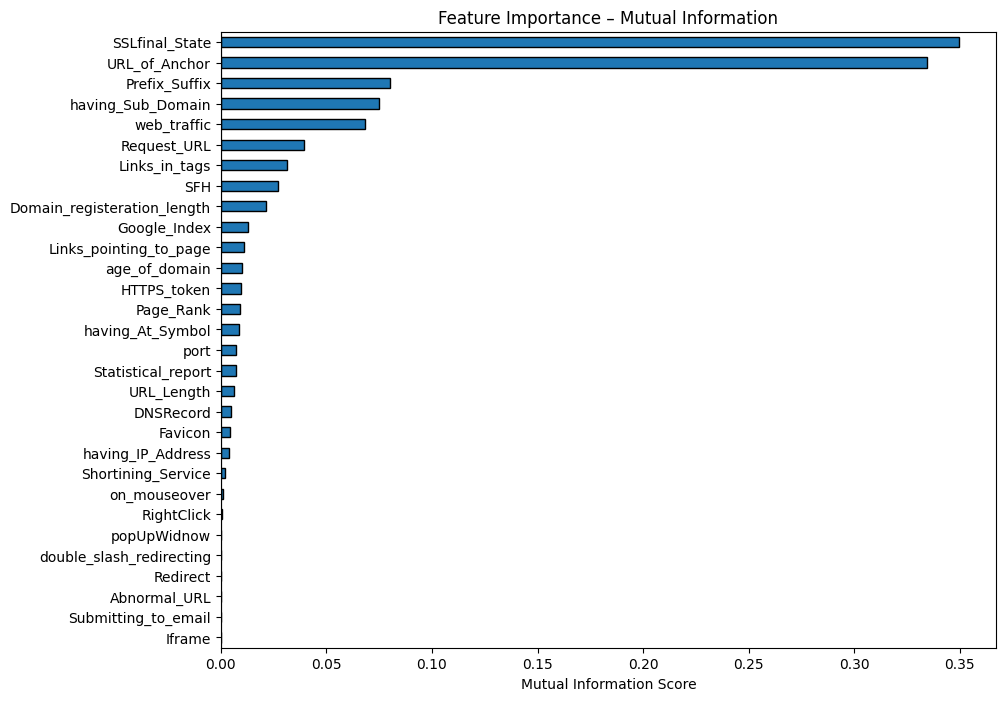

In [83]:
mi_series.plot.barh(figsize=(10, 8), edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Importance – Mutual Information')
plt.xlabel('Mutual Information Score')
plt.gca().invert_yaxis()
plt.show()

This shows us how much knowing a feature's value reduces the uncertainty about whether a site is phishing or legitimate.
* Score=0 -> the feature tells us nothing about the class
* Higher score -> the feature is more informative

Mutual information confirms that SSLFinal_state and URL_of_Anchor are by far the most informative features.

## 7. Optional Feature Extraction / Basis Expansion

Optionally test PCA or another feature extraction method. You may also try basis function expansion if it is useful for your models.


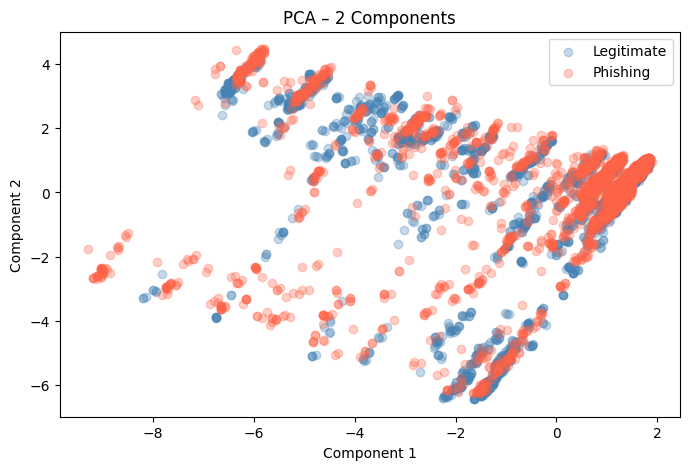

Variance explained by 2 components: 31.3%


In [121]:
# TODO: optional PCA / basis expansion experiments
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_sc)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[y_train == 0, 0], X_pca[y_train == 0, 1],
            alpha=0.3, color='steelblue', label='Legitimate')
plt.scatter(X_pca[y_train == 1, 0], X_pca[y_train == 1, 1],
            alpha=0.3, color='tomato', label='Phishing')
plt.title('PCA – 2 Components')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()
plt.show()

print(f"Variance explained by 2 components: {sum(pca.explained_variance_ratio_)*100:.1f}%")

This shows us that two components are not enough to perfectly separate phishing from legitimate sites. This also explains why models like Random Forest perform better than Linear models like LDA

## 8. Classification Models

Train and compare several classification models, such as:


- LDA
- QDA
- Naive Bayes
- Logistic Regression
- SVC
- kNN
- Neural Network
- Random Forest


In [103]:
# TODO: train multiple models
trained_models={}
def evaluate_model(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    trained_models[name] = (model, Xte)
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy_score(yte, y_pred):.3f}")
    print(classification_report(yte, y_pred, target_names=['Legitimate', 'Phishing']))
    return y_pred, y_prob

***
## LDA
***

In [104]:
y_pred_lda = evaluate_model('LDA', LinearDiscriminantAnalysis(), X_train, X_test, y_train, y_test)


=== LDA ===
Accuracy: 0.919
              precision    recall  f1-score   support

  Legitimate       0.91      0.95      0.93      1539
    Phishing       0.93      0.88      0.91      1225

    accuracy                           0.92      2764
   macro avg       0.92      0.91      0.92      2764
weighted avg       0.92      0.92      0.92      2764



***
## QDA
***

In [105]:
y_pred_qda = evaluate_model('QDA', QuadraticDiscriminantAnalysis(reg_param=0.1), X_train, X_test, y_train, y_test)


=== QDA ===
Accuracy: 0.928
              precision    recall  f1-score   support

  Legitimate       0.95      0.92      0.93      1539
    Phishing       0.91      0.93      0.92      1225

    accuracy                           0.93      2764
   macro avg       0.93      0.93      0.93      2764
weighted avg       0.93      0.93      0.93      2764



***
## Naive Bayes

***

In [106]:
y_pred_gnb = evaluate_model('Gaussian NB', GaussianNB(), X_train, X_test, y_train, y_test)


=== Gaussian NB ===
Accuracy: 0.615
              precision    recall  f1-score   support

  Legitimate       1.00      0.31      0.47      1539
    Phishing       0.53      1.00      0.70      1225

    accuracy                           0.61      2764
   macro avg       0.77      0.65      0.58      2764
weighted avg       0.79      0.61      0.57      2764



***
## Logistic Regression
***

In [107]:
y_pred_lr  = evaluate_model('Logistic Regression', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_train_sc, X_test_sc, y_train, y_test)


=== Logistic Regression ===
Accuracy: 0.931
              precision    recall  f1-score   support

  Legitimate       0.92      0.95      0.94      1539
    Phishing       0.94      0.90      0.92      1225

    accuracy                           0.93      2764
   macro avg       0.93      0.93      0.93      2764
weighted avg       0.93      0.93      0.93      2764



***
## SVC
***

In [108]:
y_pred_svc = evaluate_model('SVC', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE), X_train_sc, X_test_sc, y_train, y_test)


=== SVC ===
Accuracy: 0.955
              precision    recall  f1-score   support

  Legitimate       0.95      0.97      0.96      1539
    Phishing       0.97      0.93      0.95      1225

    accuracy                           0.96      2764
   macro avg       0.96      0.95      0.95      2764
weighted avg       0.96      0.96      0.96      2764



***
## KNN
***

In [109]:
y_pred_knn = evaluate_model('kNN', KNeighborsClassifier(n_neighbors=7), X_train_sc, X_test_sc, y_train, y_test)


=== kNN ===
Accuracy: 0.948
              precision    recall  f1-score   support

  Legitimate       0.94      0.97      0.95      1539
    Phishing       0.96      0.92      0.94      1225

    accuracy                           0.95      2764
   macro avg       0.95      0.95      0.95      2764
weighted avg       0.95      0.95      0.95      2764



***
## Neural Network
***

In [110]:
y_pred_mlp = evaluate_model('Neural Network', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=RANDOM_STATE), X_train_sc, X_test_sc, y_train, y_test)


=== Neural Network ===
Accuracy: 0.972
              precision    recall  f1-score   support

  Legitimate       0.96      0.99      0.97      1539
    Phishing       0.98      0.95      0.97      1225

    accuracy                           0.97      2764
   macro avg       0.97      0.97      0.97      2764
weighted avg       0.97      0.97      0.97      2764



***
## Random Forest
***

In [111]:
y_pred_rf  = evaluate_model('Random Forest', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), X_train, X_test, y_train, y_test)


=== Random Forest ===
Accuracy: 0.975
              precision    recall  f1-score   support

  Legitimate       0.97      0.98      0.98      1539
    Phishing       0.98      0.96      0.97      1225

    accuracy                           0.98      2764
   macro avg       0.98      0.97      0.98      2764
weighted avg       0.98      0.98      0.98      2764



## 9. Evaluation

Evaluate models using accuracy, precision, recall, F1-score, ROC-AUC, average precision, and confusion matrix. Pay special attention to phishing recall and false negatives.


In [115]:
# TODO: evaluate models and compare metrics
results = []
models = {
    'LDA': (y_pred_lda[0], y_pred_lda[1]),
    'QDA': (y_pred_qda[0], y_pred_qda[1]),
    'Gaussian NB': (y_pred_gnb[0], y_pred_gnb[1]),
    'Logistic Regression': (y_pred_lr[0], y_pred_lr[1]),
    'SVC': (y_pred_svc[0], y_pred_svc[1]),
    'kNN': (y_pred_knn[0], y_pred_knn[1]),
    'Neural Network': (y_pred_mlp[0], y_pred_mlp[1]),
    'Random Forest': (y_pred_rf[0], y_pred_rf[1])
}
for name, (y_pred, y_prob) in models.items():
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
      Random Forest    0.9754     0.9801  0.9641 0.9720   0.9963
     Neural Network    0.9718     0.9848  0.9510 0.9676   0.9961
                SVC    0.9551     0.9661  0.9314 0.9485   0.9900
                kNN    0.9483     0.9569  0.9249 0.9406   0.9886
                QDA    0.9284     0.9066  0.9347 0.9204   0.9807
Logistic Regression    0.9305     0.9388  0.9020 0.9201   0.9788
                LDA    0.9186     0.9303  0.8824 0.9057   0.9739
        Gaussian NB    0.6147     0.5350  0.9984 0.6967   0.9685


* Accuracy - the percentage of all websites that are correctly classified
* Precision - out of all websites the model predicted as phishing, how many were actually phishing
* Recall - out of all actual phishing websites, how many did the model correctly catch
* F1-score - balance between precision and recall
* ROC-AUC - measures how well the model separates phishing from legitimate sites

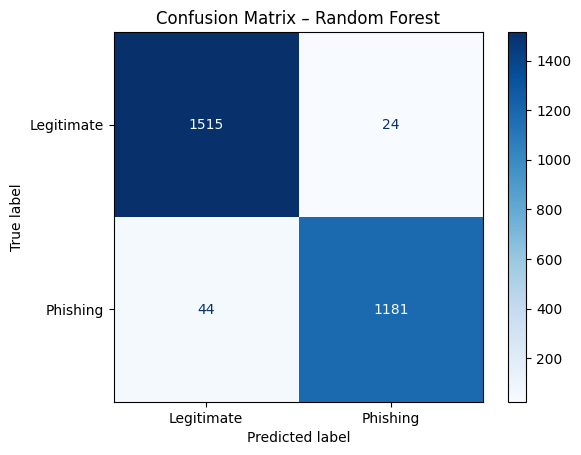

In [100]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Random Forest')
plt.show()

* The model missed 44 phishing sites (false negative, phishing sites that were wrongly predicted as legitimate).
* The model predicted 1181 phishing sites correctly.
* The model predicted 1515 sites correctly as legitimate.
* The model predicted 24 sites wrong as phishing.

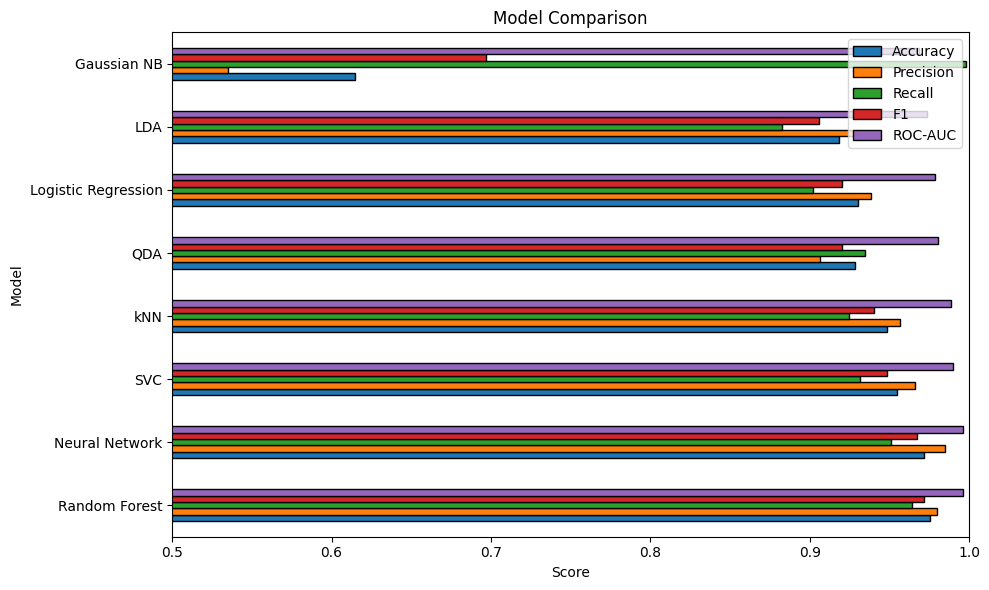

In [116]:
results_df.plot(x='Model', y=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
                kind='barh', figsize=(10, 6), edgecolor='black')
plt.title('Model Comparison')
plt.xlabel('Score')
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

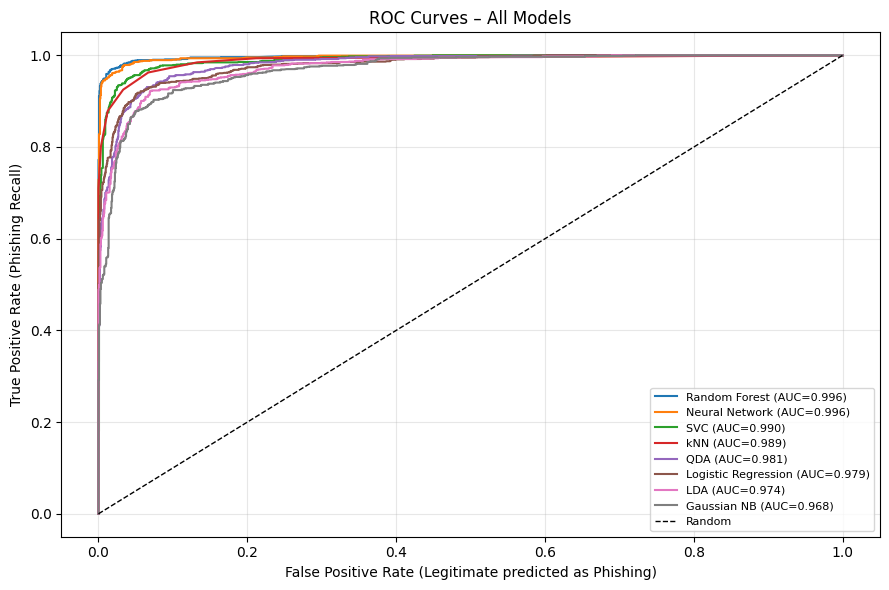

In [117]:
fig, ax = plt.subplots(figsize=(9, 6))
for name, (y_pred, y_prob) in sorted(models.items(), key=lambda x: roc_auc_score(y_test, x[1][1]), reverse=True):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=1.5)
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate (Legitimate predicted as Phishing)')
ax.set_ylabel('True Positive Rate (Phishing Recall)')
ax.set_title('ROC Curves – All Models')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We can see that almost all models perfectly separate phishing from legitimate sites.

## 10. Conclusion

Summarize the best model, the most important features, and the limitations of using older handcrafted phishing indicators.


In [119]:
# TODO: final summary table / conclusions
summary = {
    'Metric': ['Best Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Top Features', 'Weak Features'],
    'Value': ['Random Forest', '0.975', '0.980', '0.964', '0.972', '0.996',
              'SSLfinal_State, URL_of_Anchor, Prefix_Suffix',
              'RightClick, Iframe, Redirect']
}

summary_df = pd.DataFrame(summary)
summary_df

,Metric,Value
0,Best Model,Random Forest
1,Accuracy,0.975
2,Precision,0.980
3,Recall,0.964
4,F1,0.972
5,ROC-AUC,0.996
6,Top Features,"SSLfinal_State, URL_of_Anchor, Prefix_Suffix"
7,Weak Features,"RightClick, Iframe, Redirect"


* *The best model* is **Random Forest** with accuracy of 0.975, precision of 0.98 and recall of 0.96 and F1 of 0.97, which means that it correctly identified 96% of all phishing sites.
* *Most important features* are **SSLFinal_State** and **URL_of_Anchor** and that is confirmed by Mutual Information. Also **Prefix_Suffix, having_Sub_Domain and web_traffic** are good predictive features, while **RightClick, Iframe and Redirect** contributed almost no discriminative information.

